In [ ]:
# ============================================================
# 导入必要的库
# ============================================================
import math  # 数学运算，用于下采样计算
import collections  # 提供Counter等数据结构，用于词频统计
import os  # 文件系统操作
import random  # 随机数生成，用于下采样和窗口大小随机化
import torch  # PyTorch深度学习框架
from d2l import torch as d2l  # 《动手学深度学习》工具库


In [ ]:
# ============================================================
# 配置并读取 PTB 数据集
# ============================================================
# PTB (Penn Tree Bank): 宾夕法尼亚树库数据集
# - 经典的自然语言处理数据集
# - 包含来自《华尔街日报》的文章
# - 约包含 100 万词，词表约 1 万词
# - 广泛用于语言模型和词嵌入的训练

# 配置数据集的下载信息
d2l.DATA_HUB['ptb'] = (d2l.DATA_URL + 'ptb.zip',
                       '319d85e578af0cdc590547f26231e4e31cdf1e42')

def read_ptb():
    """将PTB数据集加载到文本行的列表中
    
    返回:
        句子列表，每个句子是一个词列表
        格式: [['word1', 'word2', ...], ['word3', 'word4', ...], ...]
        
    处理流程:
        1. 下载并解压数据集
        2. 读取训练集文件 ptb.train.txt
        3. 按换行符分割成句子
        4. 每个句子按空格分割成词
    """
    # 下载并解压数据集到本地
    data_dir = d2l.download_extract('ptb')
    
    # 读取训练集文件
    with open(os.path.join(data_dir, 'ptb.train.txt')) as f:
        raw_text = f.read()
    
    # 分割成句子，每个句子再分割成词
    # split('\n'): 按行分割
    # line.split(): 按空格分割每行
    return [line.split() for line in raw_text.split('\n')]

# 加载数据
sentences = read_ptb()

# 显示句子数量
print(f'# sentences数: {len(sentences)}')


'# sentences数: 42069'

In [ ]:
# ============================================================
# 构建词表
# ============================================================
# 词表（Vocabulary）：将所有唯一的词映射到整数索引

# 使用 d2l.Vocab 构建词表
# 参数说明：
#   - sentences: 句子列表
#   - min_freq=10: 最小词频阈值
#     * 只保留出现至少10次的词
#     * 低频词会被映射到特殊标记 '<unk>' (unknown)
#     * 好处：减少词表大小，过滤噪声和拼写错误

vocab = d2l.Vocab(sentences, min_freq=10)

# 显示词表大小
# 词表大小 = 有效词数 + 特殊标记（<unk>等）
print(f'vocab size: {len(vocab)}')


'vocab size: 6719'

In [ ]:
def count_corpus(tokens):  #@save
    """统计词元的频率
    
    这是一个通用的词频统计函数，可以处理1D或2D的词元列表
    
    参数:
        tokens: 词元列表
               - 1D列表: ['word1', 'word2', 'word3', ...]
               - 2D列表: [['word1', 'word2'], ['word3', 'word4'], ...]
    
    返回:
        collections.Counter 对象: 词元 -> 出现次数的映射
        如: Counter({'the': 50, 'a': 30, 'is': 25, ...})
    
    处理逻辑:
        - 如果输入是2D列表（多行文本），先展平为1D
        - 使用 collections.Counter 统计每个词元的出现次数
    """
    # 检查是否需要展平
    if len(tokens) == 0 or isinstance(tokens[0], list):
        # tokens为空 或 第一个元素是列表（说明是2D结构）
        # 使用列表推导式展平: [[1,2], [3,4]] -> [1,2,3,4]
        tokens = [token for line in tokens for token in line]
    
    # 使用Counter统计词频
    return collections.Counter(tokens)

def subsample(sentences, vocab):
    """下采样高频词
    
    问题背景:
        在自然语言中，"the", "a", "is" 等词出现频率极高
        但它们携带的语义信息相对较少
    
    影响:
        - 训练时会反复遇到这些词，浪费计算资源
        - 高频词会"淹没"其他有意义的词
        - 影响词向量的质量
    
    解决方案:
        以一定概率丢弃高频词（下采样）
    
    下采样公式 (Word2Vec论文):
        保留概率 P(w) = sqrt(t / f(w))
        
        其中:
            t: 阈值（这里是 1e-4 = 0.0001）
            f(w): 词 w 的频率
        
        特性:
            - 低频词 (f < t): P ≈ 1，几乎总是保留
            - 高频词 (f >> t): P 很小，大概率被丢弃
            - 如 "the" (频率0.05): P = sqrt(0.0001/0.05) ≈ 0.045 (95%概率丢弃)
            - 如 "learning" (频率0.0001): P = 1 (总是保留)
    
    参数:
        sentences: 句子列表
        vocab: 词表对象
        
    返回:
        subsampled: 下采样后的句子列表
        counter: 词频统计Counter对象
    """
    # 步骤1: 过滤未知词元 '<unk>'
    # 未知词是低频词的占位符，不参与训练
    sentences = [[token for token in line if vocab[token] != vocab.unk]
                 for line in sentences]
    
    # 步骤2: 统计词频
    counter = count_corpus(sentences)
    
    # 步骤3: 计算总词数
    num_tokens = sum(counter.values())

    # 步骤4: 定义保留函数
    def keep(token):
        """判断是否保留该词元
        
        返回 True 表示保留，False 表示丢弃
        
        实现:
            random.uniform(0, 1) < sqrt(t / f(w))
            
        解释:
            - 生成 [0,1) 的随机数
            - 如果随机数 < 保留概率，则保留
            - 保留概率越高，越容易保留
        """
        return(random.uniform(0, 1) <
               math.sqrt(1e-4 / counter[token] * num_tokens))

    # 步骤5: 对每个句子的每个词应用保留函数
    return ([[token for token in line if keep(token)] for line in sentences],
            counter)

# 执行下采样
subsampled, counter = subsample(sentences, vocab)


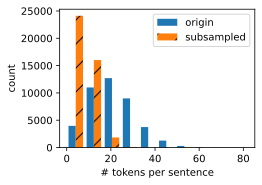

In [ ]:
# ============================================================
# 可视化: 下采样前后的句子长度分布
# ============================================================
# 对比原始数据和下采样后数据的句子长度分布
# 
# 预期效果:
#   - 下采样后的句子普遍变短（因为丢弃了高频词）
#   - 可以直观看出下采样的效果

d2l.show_list_len_pair_hist(
    ['origin', 'subsampled'],  # 图例标签
    '# tokens per sentence',    # x轴标签: 每句话的词数
    'count',                     # y轴标签: 数量
    sentences,                   # 原始句子
    subsampled);                 # 下采样后的句子


In [ ]:
# ============================================================
# 比较特定词的下采样效果
# ============================================================
def compare_counts(token):
    """比较某个词在下采样前后的出现次数
    
    参数:
        token: 要统计的词
        
    返回:
        格式化的字符串，显示下采样前后的数量
    """
    return (f'"{token}"的数量：'
            f'之前={sum([l.count(token) for l in sentences])}, '
            f'之后={sum([l.count(token) for l in subsampled])}')

# 测试高频词 "the"
# 预期: "the" 作为最高频的词，应该被大量丢弃
# 结果应该显示 "之后" 的数量远小于 "之前"
print(compare_counts('the'))


'"the"的数量：之前=50770, 之后=2034'

In [ ]:
# ============================================================
# 将文本转换为语料库（整数序列）
# ============================================================
# 神经网络不能直接处理文本，需要将词转换为整数索引

# vocab[line]: 将一个句子（词列表）转换为索引列表
# 例如: ['i', 'love', 'deep', 'learning'] -> [42, 156, 2341, 892]

corpus = [vocab[line] for line in subsampled]

# 查看前3个句子的索引表示
# 每个数字代表词表中的一个词
print(corpus[:3])


[[], [3228, 4060], [3922, 1922, 4743]]

In [ ]:
def get_centers_and_contexts(corpus, max_window_size):
    """生成 Skip-gram 模型的训练数据：中心词和上下文词对
    
    Skip-gram 核心思想:
        给定中心词，预测其周围的上下文词
        
    示例:
        句子: "I love natural language processing"
        窗口大小=2，中心词="language"
        
        上下文词可能是: "love", "natural", "processing"
        (左右各看2个词)
    
    窗口大小随机化:
        不是固定窗口，而是随机选择 1 到 max_window_size
        好处: 增加训练样本的多样性，让模型学到不同距离的词关系
    
    参数:
        corpus: 语料库，是句子的列表，每个句子是词索引的列表
               [[1, 2, 3], [4, 5, 6, 7], ...]
        max_window_size: 最大窗口大小
        
    返回:
        centers: 中心词索引列表 [1, 2, 3, 1, 2, ...]
        contexts: 对应的上下文词索引列表 [[2, 3], [1, 3, 4], ...]
                 注意: 每个中心词的上下文数量可能不同
    """
    centers, contexts = [], []
    
    # 遍历每个句子
    for line in corpus:
        # 要形成"中心词-上下文词"对，每个句子至少需要2个词
        if len(line) < 2:
            continue
        
        # 将句子中的每个词都作为中心词
        centers += line
        
        # 为每个词生成其上下文
        for i in range(len(line)):  # i 是中心词的位置
            # 随机选择窗口大小（1 到 max_window_size）
            # 这是一个重要的技巧，增加样本多样性
            window_size = random.randint(1, max_window_size)
            
            # 计算上下文窗口的索引范围
            # 左边界: max(0, i - window_size)
            # 右边界: min(len(line), i + 1 + window_size)
            indices = list(range(max(0, i - window_size),
                                 min(len(line), i + 1 + window_size)))
            
            # 从上下文词中排除中心词自己
            indices.remove(i)
            
            # 收集上下文词
            contexts.append([line[idx] for idx in indices])
    
    return centers, contexts


In [ ]:
# ============================================================
# 测试: 使用小数据集演示中心词和上下文词的生成
# ============================================================
# 创建一个简单的测试数据集
# [0, 1, 2, 3, 4, 5, 6] 和 [7, 8, 9]
tiny_dataset = [list(range(7)), list(range(7, 10))]
print('数据集', tiny_dataset)

# 生成并打印每个中心词及其上下文词
# 窗口大小设为2
for center, context in zip(*get_centers_and_contexts(tiny_dataset, 2)):
    print('中心词', center, '的上下文词是', context)

# 预期输出示例:
# 中心词 0 的上下文词是 [1]        (只有右边的词)
# 中心词 1 的上下文词是 [0, 2, 3]  (左边1个，右边2个，因为窗口随机)
# 中心词 2 的上下文词是 [0, 1, 3]  (窗口大小随机为2)
# ...


数据集 [[0, 1, 2, 3, 4, 5, 6], [7, 8, 9]]
中心词 0 的上下文词是 [1, 2]
中心词 1 的上下文词是 [0, 2]
中心词 2 的上下文词是 [0, 1, 3, 4]
中心词 3 的上下文词是 [1, 2, 4, 5]
中心词 4 的上下文词是 [3, 5]
中心词 5 的上下文词是 [4, 6]
中心词 6 的上下文词是 [4, 5]
中心词 7 的上下文词是 [8, 9]
中心词 8 的上下文词是 [7, 9]
中心词 9 的上下文词是 [7, 8]


In [ ]:
# ============================================================
# 为整个语料库生成中心词-上下文词对
# ============================================================
# 使用最大窗口大小为5
all_centers, all_contexts = get_centers_and_contexts(corpus, 5)

# 统计生成的训练样本对数量
# sum([len(contexts) for contexts in all_contexts]):
#   计算所有上下文词的总数
# 注意: 这个数量远大于词汇数量，因为:
#   - 每个词都会作为多次中心词（在不同句子中）
#   - 每个中心词有多个上下文词
f'# "中心词-上下文词对"的数量: {sum([len(contexts) for contexts in all_contexts])}'


'# “中心词-上下文词对”的数量: 1500754'

In [ ]:
class RandomGenerator:
    """带权重的随机采样生成器（优化版）
    
    功能:
        根据给定的采样权重，从 {1, 2, ..., n} 中随机抽取元素
        
    优化策略:
        预先生成一批随机样本（k=10000），缓存起来
        每次调用 draw() 时从缓存中取，而不是每次都重新采样
        
    为什么要优化？
        - random.choices() 每次调用有开销
        - 负采样需要调用非常多次（数百万次）
        - 批量生成+缓存可以显著提升速度（10倍以上）
    
    应用场景:
        负采样（Negative Sampling）中需要频繁采样负样本
    """
    
    def __init__(self, sampling_weights):
        """初始化随机生成器
        
        参数:
            sampling_weights: 采样权重列表
                            权重越大，被采样的概率越高
        """
        # population: 候选元素列表 [1, 2, 3, ..., n]
        # 注意: 从1开始，因为索引0通常是特殊标记（如<unk>）
        self.population = list(range(1, len(sampling_weights) + 1))
        
        # 采样权重
        self.sampling_weights = sampling_weights
        
        # 缓存区: 存储预先生成的随机样本
        self.candidates = []
        
        # 当前读取位置
        self.i = 0

    def draw(self):
        """抽取一个随机样本
        
        返回:
            随机抽取的元素（带权重）
        """
        # 如果缓存已用完，重新生成一批
        if self.i == len(self.candidates):
            # 一次性生成 10000 个随机样本
            # random.choices: 带权重的随机选择
            # k=10000: 生成10000个样本
            self.candidates = random.choices(
                self.population, self.sampling_weights, k=10000)
            self.i = 0  # 重置读取位置
        
        # 从缓存中取一个样本
        self.i += 1
        return self.candidates[self.i - 1]


In [ ]:
# ============================================================
# 测试 RandomGenerator
# ============================================================
# 创建一个生成器，权重为 [2, 3, 4]
# 意味着:
#   - 元素1的采样概率 ∝ 2
#   - 元素2的采样概率 ∝ 3
#   - 元素3的采样概率 ∝ 4
# 因此元素3最容易被抽到，元素1最不容易

generator = RandomGenerator([2, 3, 4])

# 抽取10个样本
# 预期: 元素3出现最多，元素1出现最少
[generator.draw() for _ in range(10)]


[3, 3, 3, 2, 1, 3, 3, 2, 2, 2]

In [ ]:
def get_negatives(all_contexts, vocab, counter, K):
    """生成负采样的噪声词（负样本）
    
    负采样（Negative Sampling）:
        Skip-gram 的核心优化技术
        
    原理:
        - 正样本: 真实的上下文词（标签=1）
        - 负样本: 随机采样的非上下文词（标签=0）
        
    为什么需要负样本？
        - 传统方法需要计算整个词表的 Softmax，复杂度 O(V)
        - 负采样只需要1个正样本 + K个负样本，复杂度 O(K)
        - 训练速度提升 100+ 倍
    
    负采样权重公式 (Word2Vec 论文):
        P(w) ∝ freq(w)^0.75
        
        为什么用 0.75 次方？
        - freq(w)^1.0: 高频词被过度采样
        - freq(w)^0.0: 均匀分布，低频词被过度采样
        - freq(w)^0.75: 经验最优值，平衡高低频词
    
    参数:
        all_contexts: 所有中心词的上下文词列表
                     [[ctx1_1, ctx1_2], [ctx2_1], ...]
        vocab: 词表对象
        counter: 词频统计Counter对象
        K: 每个上下文词对应的负样本数量（通常5-20）
        
    返回:
        all_negatives: 负样本列表，结构与 all_contexts 对应
                      [[neg1_1, neg1_2, ...], [neg2_1, ...], ...]
    """
    # 步骤1: 计算负采样权重
    # 索引从1开始，因为索引0是 '<unk>' 标记，通常不参与采样
    sampling_weights = [counter[vocab.to_tokens(i)]**0.75
                        for i in range(1, len(vocab))]
    
    # 步骤2: 初始化
    all_negatives = []  # 存储所有负样本
    generator = RandomGenerator(sampling_weights)  # 创建随机生成器
    
    # 步骤3: 为每个中心词生成负样本
    for contexts in all_contexts:
        negatives = []
        
        # 生成 len(contexts) * K 个负样本
        # 每个上下文词对应 K 个负样本
        while len(negatives) < len(contexts) * K:
            # 从词表中随机采样一个词
            neg = generator.draw()
            
            # 重要: 噪声词不能是真实的上下文词
            # 否则会产生矛盾的训练信号
            if neg not in contexts:
                negatives.append(neg)
        
        all_negatives.append(negatives)
    
    return all_negatives

# 生成负样本
# K=5: 每个上下文词对应5个负样本
all_negatives = get_negatives(all_contexts, vocab, counter, 5)


In [ ]:
def batchify(data):
    """将样本批处理为小批量，用于训练
    
    问题:
        在一个批次中，不同样本的上下文词数量可能不同
        例如:
            样本1: 中心词=5, 上下文=[1, 2], 负样本=[7, 8, 9, 10]
            样本2: 中心词=3, 上下文=[6, 7, 8], 负样本=[4, 5]
        
        上下文数不同(2 vs 3)，负样本数也不同(4 vs 2)
    
    解决方案:
        填充（Padding）到同一长度
        
    数据结构:
        每个样本是一个三元组: (center, context, negative)
        - center: 中心词索引（标量）
        - context: 上下文词索引列表
        - negative: 负样本索引列表
    
    参数:
        data: 样本列表 [(center1, context1, neg1), (center2, context2, neg2), ...]
        
    返回:
        centers: 中心词张量, 形状 (batch_size, 1)
        contexts_negatives: 上下文词+负样本张量, 形状 (batch_size, max_len)
        masks: 掩码张量, 形状 (batch_size, max_len)
              1表示有效位置, 0表示填充位置
        labels: 标签张量, 形状 (batch_size, max_len)
               1表示正样本(上下文词), 0表示负样本或填充
    """
    # 步骤1: 找出批次中最长的序列长度
    # len(c) + len(n): 上下文词数 + 负样本数
    max_len = max(len(c) + len(n) for _, c, n in data)
    
    # 步骤2: 初始化四个列表
    centers, contexts_negatives, masks, labels = [], [], [], []
    
    # 步骤3: 处理每个样本
    for center, context, negative in data:
        # 计算当前样本的实际长度
        cur_len = len(context) + len(negative)
        
        # 中心词 (标量)
        centers += [center]
        
        # 拼接上下文词和负样本，并填充到 max_len
        # [上下文词] + [负样本] + [填充0]
        contexts_negatives += \
            [context + negative + [0] * (max_len - cur_len)]
        
        # 掩码: 标记哪些位置是有效的
        # [1, 1, ..., 1 (cur_len个), 0, 0, ..., 0 (填充部分)]
        masks += [[1] * cur_len + [0] * (max_len - cur_len)]
        
        # 标签: 上下文词标记为1，其余标记为0
        # [1, 1, ..., 1 (len(context)个), 0, 0, ..., 0 (负样本+填充)]
        labels += [[1] * len(context) + [0] * (max_len - len(context))]
    
    # 步骤4: 转换为张量
    return (torch.tensor(centers).reshape((-1, 1)),  # (batch, 1)
            torch.tensor(contexts_negatives),         # (batch, max_len)
            torch.tensor(masks),                      # (batch, max_len)
            torch.tensor(labels))                     # (batch, max_len)


In [ ]:
# ============================================================
# 测试 batchify 函数
# ============================================================
# 创建两个测试样本
# 样本1: 中心词=1, 上下文=[2, 2], 负样本=[3, 3, 3, 3]
x_1 = (1, [2, 2], [3, 3, 3, 3])

# 样本2: 中心词=1, 上下文=[2, 2, 2], 负样本=[3, 3]
x_2 = (1, [2, 2, 2], [3, 3])

# 批处理这两个样本
batch = batchify((x_1, x_2))

# 打印结果
names = ['centers', 'contexts_negatives', 'masks', 'labels']
for name, data in zip(names, batch):
    print(name, '=', data)

# 预期输出:
# centers = tensor([[1], [1]])  # 两个中心词
# contexts_negatives = tensor([[2, 2, 3, 3, 3, 3, 0],  # 样本1，填充1个0
#                              [2, 2, 2, 3, 3, 0, 0]])  # 样本2，填充2个0
# masks = tensor([[1, 1, 1, 1, 1, 1, 0],   # 样本1: 6个有效位置
#                 [1, 1, 1, 1, 1, 0, 0]])  # 样本2: 5个有效位置
# labels = tensor([[1, 1, 0, 0, 0, 0, 0],  # 样本1: 前2个是正样本
#                  [1, 1, 1, 0, 0, 0, 0]]) # 样本2: 前3个是正样本


centers = tensor([[1],
        [1]])
contexts_negatives = tensor([[2, 2, 3, 3, 3, 3],
        [2, 2, 2, 3, 3, 0]])
masks = tensor([[1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 0]])
labels = tensor([[1, 1, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0]])


In [ ]:
def load_data_ptb(batch_size, max_window_size, num_noise_words):
    """完整的数据加载流程：从原始文本到训练迭代器
    
    这是一个端到端的数据处理函数，整合了所有前面的步骤：
    1. 读取PTB数据集
    2. 构建词表
    3. 下采样高频词
    4. 转换为语料库（整数序列）
    5. 生成中心词-上下文词对
    6. 生成负样本
    7. 创建数据集和数据加载器
    
    参数:
        batch_size: 批次大小，每次训练使用的样本数
        max_window_size: 最大上下文窗口大小
        num_noise_words: 每个上下文词对应的负样本数量
        
    返回:
        data_iter: PyTorch数据迭代器，可用于训练循环
        vocab: 词表对象，用于词和索引的转换
    """
    # 步骤1: 获取数据加载器的工作进程数
    # 多进程可以加速数据加载
    num_workers = d2l.get_dataloader_workers()
    
    # 步骤2: 读取PTB数据集
    sentences = read_ptb()
    
    # 步骤3: 构建词表（过滤低频词）
    vocab = d2l.Vocab(sentences, min_freq=10)
    
    # 步骤4: 下采样高频词
    subsampled, counter = subsample(sentences, vocab)
    
    # 步骤5: 转换为语料库（词索引序列）
    corpus = [vocab[line] for line in subsampled]
    
    # 步骤6: 生成中心词和上下文词
    all_centers, all_contexts = get_centers_and_contexts(
        corpus, max_window_size)
    
    # 步骤7: 生成负样本
    all_negatives = get_negatives(
        all_contexts, vocab, counter, num_noise_words)

    # 步骤8: 定义 PyTorch 数据集类
    class PTBDataset(torch.utils.data.Dataset):
        """PTB数据集的PyTorch包装类
        
        PyTorch的Dataset需要实现三个方法：
        - __init__: 初始化
        - __getitem__: 根据索引返回一个样本
        - __len__: 返回数据集大小
        """
        
        def __init__(self, centers, contexts, negatives):
            # 确保三个列表长度相同
            assert len(centers) == len(contexts) == len(negatives)
            self.centers = centers
            self.contexts = contexts
            self.negatives = negatives

        def __getitem__(self, index):
            """返回第 index 个样本
            
            返回:
                (中心词, 上下文词列表, 负样本列表)
            """
            return (self.centers[index], self.contexts[index],
                    self.negatives[index])

        def __len__(self):
            """返回数据集大小"""
            return len(self.centers)

    # 步骤9: 创建数据集实例
    dataset = PTBDataset(all_centers, all_contexts, all_negatives)

    # 步骤10: 创建数据加载器
    # DataLoader 负责:
    #   - 批处理 (batch_size)
    #   - 打乱数据 (shuffle=True)
    #   - 并行加载 (num_workers)
    #   - 自定义批处理函数 (collate_fn=batchify)
    data_iter = torch.utils.data.DataLoader(
        dataset, batch_size, shuffle=True,
        collate_fn=batchify,  # 使用我们自定义的批处理函数
        num_workers=num_workers)
    
    return data_iter, vocab


In [ ]:
# ============================================================
# 测试完整的数据加载流程
# ============================================================
# 创建数据迭代器和词表
# 参数:
#   - batch_size=512: 每批512个样本
#   - max_window_size=5: 最大上下文窗口为5
#   - num_noise_words=5: 每个上下文词对应5个负样本
data_iter, vocab = load_data_ptb(512, 5, 5)

# 从迭代器中取出第一个批次，查看数据形状
for batch in data_iter:
    for name, data in zip(names, batch):
        print(name, 'shape:', data.shape)
    break  # 只看第一个批次

# 预期输出示例:
# centers shape: torch.Size([512, 1])              # 512个中心词
# contexts_negatives shape: torch.Size([512, 60])  # 每个样本最多60个词（上下文+负样本）
# masks shape: torch.Size([512, 60])               # 掩码，标记有效位置
# labels shape: torch.Size([512, 60])              # 标签，区分正负样本

# 注意:
# - 第二维的大小(60)取决于批次中最长的序列
# - 不同批次的第二维大小可能不同
# - 这些数据可以直接用于训练 Skip-gram 模型


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


centers shape: torch.Size([512, 1])
contexts_negatives shape: torch.Size([512, 60])
masks shape: torch.Size([512, 60])
labels shape: torch.Size([512, 60])
